# 01 — Análise exploratória das sessões de recarga

Este notebook é a primeira etapa do módulo de IA do **EV ChargeOps**. O objetivo é entender o comportamento real de recarga de veículos elétricos antes de treinar qualquer modelo, respondendo a quatro perguntas:

1. Quanta energia uma sessão consome e quanto tempo o carro fica conectado?
2. Em que horários e dias as recargas começam?
3. Qual a ocupação dos carregadores ao longo do dia e com que frequência a demanda passa da capacidade?
4. Quanto do tempo conectado o carro fica **parado sem carregar** (tempo ocioso)?

As respostas orientam os dois modelos do módulo: o **fator de demanda** (tarifa dinâmica por kWh) e a **detecção de anomalias** nas sessões.

## Fontes de dados

Usamos dois conjuntos de dados públicos, ambos com licença **CC BY 4.0**, baixados pelo script `uv run python -m ml.data.download`. Os arquivos ficam em `data/raw/` (fora do Git) e o download confere o MD5 publicado no Zenodo. Uma amostra pequena fica versionada em `data/sample/sessions.csv` para os testes automatizados.

| Tipo no EV ChargeOps | Fonte | O que contém |
|---|---|---|
| `PRIVATE` (uso residencial compartilhado) | Sørensen, Å. L. *Electric vehicle charging dataset with 35,000 charging sessions from 12 residential locations in Norway*. Zenodo, 2024. DOI 10.5281/zenodo.13896176 (artigo: Data in Brief, DOI 10.1016/j.dib.2024.110883) | ~35 mil sessões em 12 garagens residenciais compartilhadas na Noruega (2018–2021): conexão, desconexão, energia e estimativa de tempo ocioso |
| `COMMERCIAL` (uso rotativo/público) | Andrenacci, N.; Bosch, R.; Kulla, A. *Supporting data to the paper "Modelling charge profiles of electric vehicles based on charges data"*. Zenodo, 2021. DOI 10.5281/zenodo.5721233 | ~7,7 mil sessões em 18 estações públicas da Turku Energia (Turku, Finlândia, 2019), AC 22 kW e DC 50 kW |

**Por que esses dados?** O cenário do EV ChargeOps é um condomínio com carregadores compartilhados. O conjunto norueguês é exatamente isso: garagens residenciais onde vários moradores dividem pontos de recarga. Para o uso `COMMERCIAL` (visitantes, uso rotativo) usamos estações públicas, que têm o padrão diurno típico desse uso.

**Limitações que precisam ficar claras:**

- Os dados são da Noruega e da Finlândia, não do Brasil. Os padrões de horário (chegar em casa à noite e carregar de madrugada) tendem a se repetir, mas clima, tarifas e frota são diferentes.
- O **tempo ocioso** das sessões norueguesas é uma estimativa feita pelos autores do conjunto de dados a partir da potência estimada de cada veículo. Nas sessões de Turku essa informação não existe: estimamos o tempo carregando como `energia / potência efetiva` e tratamos o restante da conexão como ocioso. A potência efetiva é o percentil 90 da potência média observada em Turku: 3,7 kW em AC (o valor de um carregador embarcado monofásico de 16 A, o mais comum na amostra) e 37 kW em DC. Carros que carregam mais rápido que isso ficam com ocioso zero, então a estimativa é conservadora.
- Nenhuma fonte registra **fila**. Ocupação e fila são derivadas da sobreposição das sessões (seção 4).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ml.config import COMMERCIAL, PRIVATE
from ml.data.hourly import build_hourly_panel
from ml.data.loaders import (
    MAX_AVERAGE_POWER_KW,
    MAX_DURATION_MINUTES,
    MIN_DURATION_MINUTES,
    MIN_ENERGY_KWH,
    load_sessions,
)
from ml.training.datasets import build_demand_dataset

pd.set_option("display.precision", 2)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)
COLORS = {PRIVATE: "#2a78d6", COMMERCIAL: "#eb6834"}
TYPES = [PRIVATE, COMMERCIAL]
WEEKDAYS = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

## 1. Visão geral

Os dois conjuntos são convertidos para um formato único (`ml.data.loaders.load_sessions`): uma linha por sessão, com local, tipo de ponto, horários de conexão e desconexão, energia (kWh), duração e tempo ocioso (minutos). A potência média é `energia / duração da conexão`.

In [2]:
sessions = load_sessions()
sessions.groupby("charge_point_type").agg(
    sessions=("session_id", "size"),
    sites=("site_id", "nunique"),
    first_session=("plugin_time", "min"),
    last_session=("plugin_time", "max"),
)

,sessions,sites,first_session,last_session
charge_point_type,,,,
COMMERCIAL,7737,18,2019-01-01 01:47:00,2019-12-31 18:16:00
PRIVATE,35377,12,2018-02-06 14:42:00,2021-08-05 20:50:00


### Qualidade dos dados

Antes de analisar distribuições, marcamos como **inválidas** as sessões que não representam uma recarga real ou que têm erro de medição. As regras (em `ml.data.loaders.is_valid_session`) são:

- energia abaixo de 0,5 kWh (conexões sem recarga efetiva, medidor zerado ou negativo);
- duração abaixo de 5 minutos ou acima de 72 horas;
- potência média acima do limite físico do ponto (22 kW residencial, 50 kW público);
- tempo ocioso desconhecido.

Uma mesma sessão pode cair em mais de uma regra.

In [3]:
rules = pd.DataFrame(
    {
        "energia < 0,5 kWh": sessions["energy_kwh"] < MIN_ENERGY_KWH,
        "duração < 5 min": sessions["duration_minutes"] < MIN_DURATION_MINUTES,
        "duração > 72 h": sessions["duration_minutes"] > MAX_DURATION_MINUTES,
        "potência acima do limite": sessions["average_power_kw"]
        > sessions["charge_point_type"].map(MAX_AVERAGE_POWER_KW),
        "ocioso desconhecido": sessions["idle_minutes"].isna(),
        "sessão válida": sessions["is_valid"],
    }
)
summary = rules.groupby(sessions["charge_point_type"]).mean().T * 100
summary.round(1).rename(columns=lambda c: f"{c} (%)")

charge_point_type,COMMERCIAL (%),PRIVATE (%)
"energia < 0,5 kWh",19.6,1.2
duração < 5 min,10.1,0.3
duração > 72 h,0.4,0.8
potência acima do limite,0.0,0.0
ocioso desconhecido,0.0,2.9
sessão válida,79.8,95.3


**Leitura:** no uso residencial (`PRIVATE`) 95% das sessões são aproveitáveis; as perdas vêm principalmente de sessões sem estimativa de tempo ocioso (2,9%) e de conexões de mais de 72 horas (0,8%), típicas de carros deixados na garagem durante viagens. No uso público (`COMMERCIAL`) só 80% são válidas: cerca de 20% das conexões entregam menos de 0,5 kWh e 10% duram menos de 5 minutos. São tentativas de recarga que falharam, testes ou erros de cabo. Essas sessões não entram no treino dos modelos, mas mostram que o sistema precisa lidar com sessões curtas e vazias como evento normal de operação, e não como fraude.

## 2. Energia, duração e tempo ocioso por sessão

A partir daqui usamos apenas as sessões válidas.

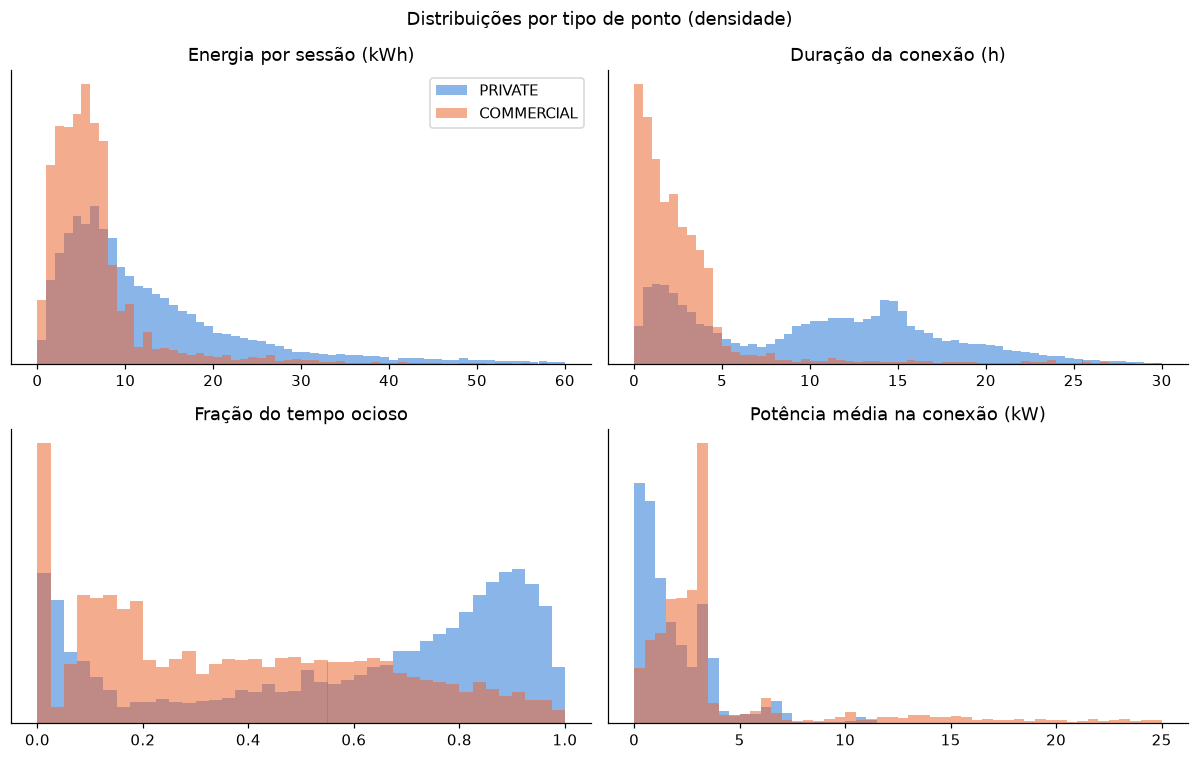

In [4]:
valid = sessions[sessions["is_valid"]].copy()
valid["duration_hours"] = valid["duration_minutes"] / 60
valid["idle_share"] = valid["idle_minutes"] / valid["duration_minutes"]

metrics = {
    "energy_kwh": ("Energia por sessão (kWh)", np.linspace(0, 60, 61)),
    "duration_hours": ("Duração da conexão (h)", np.linspace(0, 30, 61)),
    "idle_share": ("Fração do tempo ocioso", np.linspace(0, 1, 41)),
    "average_power_kw": ("Potência média na conexão (kW)", np.linspace(0, 25, 51)),
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (column, (title, bins)) in zip(axes.flat, metrics.items()):
    for charge_point_type in TYPES:
        values = valid.loc[valid["charge_point_type"] == charge_point_type, column]
        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.55,
            color=COLORS[charge_point_type],
            label=charge_point_type,
        )
    ax.set_title(title)
    ax.set_yticks([])
axes[0, 0].legend()
fig.suptitle("Distribuições por tipo de ponto (densidade)")
fig.tight_layout()

In [5]:
valid.groupby("charge_point_type")[
    ["energy_kwh", "duration_hours", "idle_share", "average_power_kw"]
].quantile([0.1, 0.5, 0.9]).unstack(0).T

0.1    0.5    0.9
                 charge_point_type                    
energy_kwh       COMMERCIAL         1.80   5.33  11.17
                 PRIVATE            2.98   9.28  27.19
duration_hours   COMMERCIAL         0.35   1.92   4.75
                 PRIVATE            1.40  11.07  21.48
idle_share       COMMERCIAL         0.00   0.33   0.78
                 PRIVATE            0.05   0.72   0.93
average_power_kw COMMERCIAL         0.89   2.97  15.67
                 PRIVATE            0.29   1.33   3.71

**Leitura:**

- **Energia:** a sessão residencial típica consome cerca de 9 kWh (mediana) e 10% passam de 27 kWh. Na pública a mediana é 5 kWh. Para o rateio do condomínio isso significa que poucas sessões grandes concentram boa parte do consumo, o que justifica cobrar por kWh medido, e não um valor fixo por recarga.
- **Duração:** em casa o carro fica conectado em média 11 horas (mediana), quase sempre a noite inteira. Na estação pública a mediana é de 2 horas.
- **Tempo ocioso:** este é o achado mais importante para o condomínio. Na sessão residencial mediana, **72% do tempo conectado é ocioso**: o carro termina de carregar e continua ocupando o ponto. A potência média ao longo da conexão é de só 1,3 kW, muito abaixo do que o carregador entrega. Em um condomínio com poucos carregadores compartilhados, é esse tempo ocioso que gera fila, e não a energia em si. Na estação pública o ocioso estimado é menor (mediana de 33%), mas lembre que ali ele é uma estimativa conservadora.
- **Potência:** no uso público aparece uma cauda de 10 a 50 kW, que são as recargas rápidas em DC.

## 3. Quando as recargas começam

O mapa de calor mostra a porcentagem das sessões de cada tipo que começa em cada combinação de dia da semana e hora.

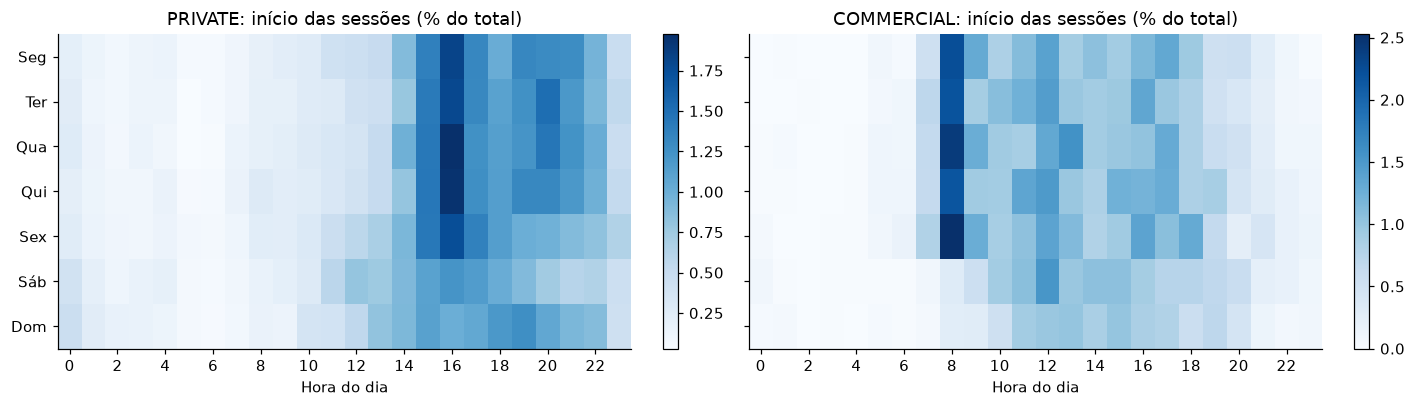

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, charge_point_type in zip(axes, TYPES):
    subset = valid[valid["charge_point_type"] == charge_point_type]
    heat = (
        pd.crosstab(subset["day_of_week"], subset["start_hour"], normalize="all") * 100
    )
    heat = heat.reindex(index=range(7), columns=range(24), fill_value=0)
    image = ax.imshow(heat, aspect="auto", cmap="Blues")
    ax.set_title(f"{charge_point_type}: início das sessões (% do total)")
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel("Hora do dia")
    ax.set_yticks(range(7), WEEKDAYS)
    fig.colorbar(image, ax=ax, fraction=0.03)
fig.tight_layout()

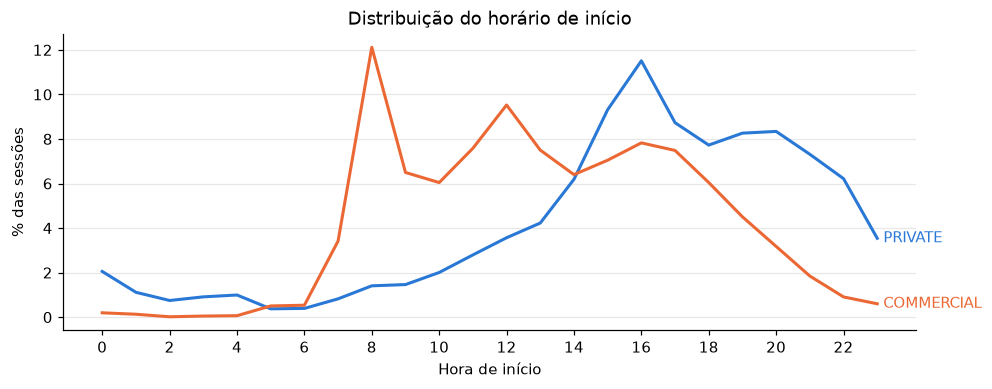

In [7]:
starts = (
    valid.groupby(["charge_point_type", "start_hour"]).size().unstack(0).fillna(0)
    / valid.groupby("charge_point_type").size()
    * 100
)
fig, ax = plt.subplots(figsize=(10, 3.5))
for charge_point_type in TYPES:
    ax.plot(
        starts.index, starts[charge_point_type], color=COLORS[charge_point_type], lw=2
    )
    ax.annotate(
        charge_point_type,
        (starts.index[-1], starts[charge_point_type].iloc[-1]),
        xytext=(4, 0),
        textcoords="offset points",
        color=COLORS[charge_point_type],
        va="center",
    )
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hora de início")
ax.set_ylabel("% das sessões")
ax.set_title("Distribuição do horário de início")
ax.grid(axis="y", alpha=0.3)

**Leitura:** os dois usos têm horários quase opostos.

- `PRIVATE`: as recargas começam a partir das 14h, com pico às 16h nos dias úteis (chegada do trabalho), e continuam fortes até as 22h. No fim de semana a chegada se espalha ao longo da tarde.
- `COMMERCIAL`: pico às 8h nos dias úteis (chegada ao trabalho ou ao centro) e atividade espalhada até as 18h. Fins de semana têm movimento menor (sábado 12% e domingo 10% das sessões, contra 15–16% em cada dia útil).

Para a tarifa dinâmica, isso mostra que **hora do dia e tipo de ponto precisam entrar juntos no modelo**: a mesma hora pode ser pico em um tipo de ponto e vale no outro.

## 4. Ocupação e fila por hora

Os dados são de sessões, mas o modelo de tarifa precisa do estado do estacionamento **hora a hora**. A função `ml.data.hourly.build_hourly_panel` faz essa conversão para cada local:

1. Calcula, minuto a minuto, quantos carros estão conectados. Sessões sem horário de desconexão ou com mais de 72 horas ficam de fora.
2. Define a **capacidade** do local como o percentil 95 da média horária de carros conectados, arredondado para cima. Os conjuntos de dados não informam quantos carregadores existem, então usamos como proxy o nível de uso que o local sustenta em 95% das horas.
3. `occupancy_ratio` = carros conectados **no início da hora** / capacidade, limitado a 1. É uma foto do estado atual, igual à que o backend do EV ChargeOps tem no momento em que um morador inicia uma recarga.
4. `queue_length` = carros conectados no início da hora acima da capacidade. É uma **fila estimada**: quantos estariam esperando se o local tivesse exatamente aquela capacidade.
5. `demand_index` = média de carros conectados ao longo da hora / capacidade. Diferente da ocupação, pode passar de 1. É a medida de demanda que o modelo do notebook 02 tenta prever.
6. Semanas sem nenhuma sessão são removidas, porque indicam falha de coleta, e não ausência de demanda.

In [8]:
panel = build_hourly_panel(sessions)
panel.groupby("charge_point_type").agg(
    hours=("timestamp", "size"),
    sites=("site_id", "nunique"),
    mean_capacity=("capacity", "mean"),
    mean_occupancy=("occupancy_ratio", "mean"),
    hours_with_queue_pct=("queue_length", lambda q: (q > 0).mean() * 100),
    max_queue=("queue_length", "max"),
)

,hours,sites,mean_capacity,mean_occupancy,hours_with_queue_pct,max_queue
charge_point_type,,,,,,
COMMERCIAL,124996,18,1.00,0.18,0.01,1
PRIVATE,103766,12,9.34,0.42,2.05,7


In [9]:
panel[panel["charge_point_type"] == PRIVATE].groupby("site_id")[
    "capacity"
].first().to_frame().T

site_id,NO_ASK,NO_BAR,NO_BAR_2,NO_BER,NO_BOD,NO_KRO,NO_OSL_1,NO_OSL_2,NO_OSL_S,NO_OSL_T,NO_TRO,NO_TRO_R
capacity,13,6,3,4,2,6,5,2,12,12,7,25


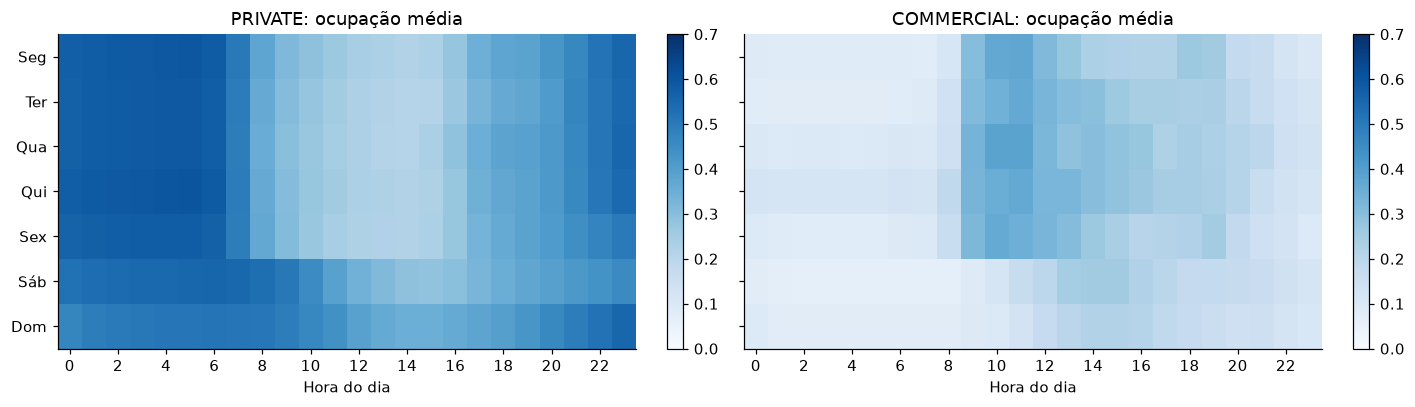

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, charge_point_type in zip(axes, TYPES):
    subset = panel[panel["charge_point_type"] == charge_point_type]
    heat = subset.pivot_table(
        index="day_of_week", columns="hour", values="occupancy_ratio", aggfunc="mean"
    )
    image = ax.imshow(heat, aspect="auto", cmap="Blues", vmin=0, vmax=0.7)
    ax.set_title(f"{charge_point_type}: ocupação média")
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel("Hora do dia")
    ax.set_yticks(range(7), WEEKDAYS)
    fig.colorbar(image, ax=ax, fraction=0.03)
fig.tight_layout()

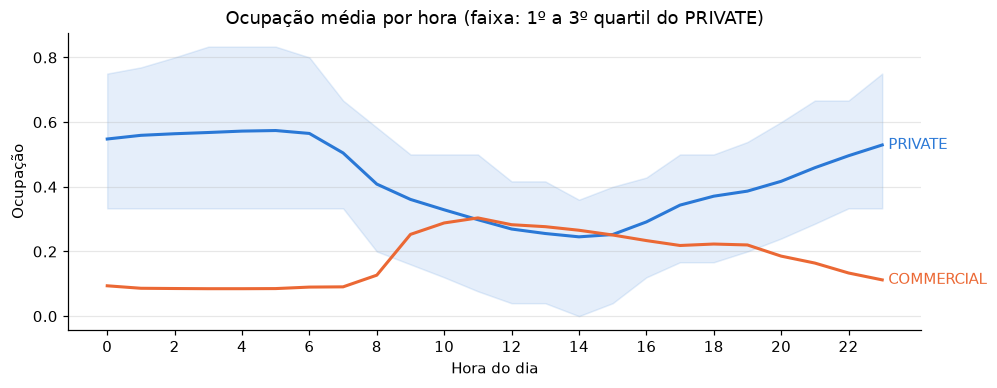

In [11]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for charge_point_type in TYPES:
    hourly = panel[panel["charge_point_type"] == charge_point_type].groupby("hour")[
        "occupancy_ratio"
    ]
    ax.plot(hourly.mean().index, hourly.mean(), color=COLORS[charge_point_type], lw=2)
    if charge_point_type == PRIVATE:
        ax.fill_between(
            hourly.mean().index,
            hourly.quantile(0.25),
            hourly.quantile(0.75),
            color=COLORS[charge_point_type],
            alpha=0.12,
        )
    ax.annotate(
        charge_point_type,
        (23, hourly.mean().iloc[-1]),
        xytext=(4, 0),
        textcoords="offset points",
        color=COLORS[charge_point_type],
        va="center",
    )
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Ocupação")
ax.set_title("Ocupação média por hora (faixa: 1º a 3º quartil do PRIVATE)")
ax.grid(axis="y", alpha=0.3)

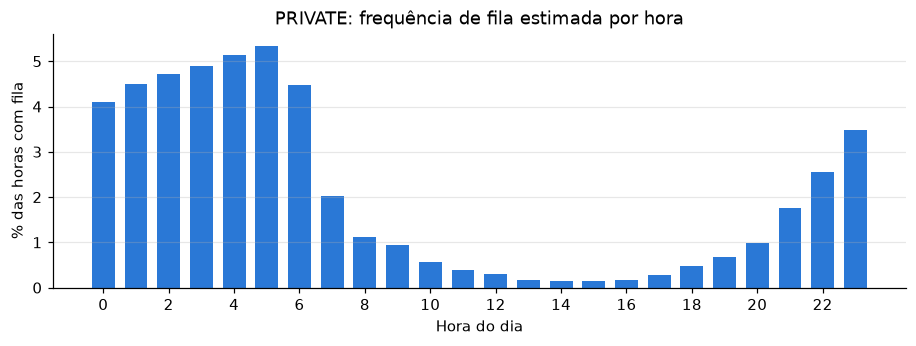

In [12]:
queue_by_hour = (
    panel[panel["charge_point_type"] == PRIVATE]
    .groupby("hour")["queue_length"]
    .apply(lambda q: (q > 0).mean() * 100)
)
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(queue_by_hour.index, queue_by_hour.values, color=COLORS[PRIVATE], width=0.7)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hora do dia")
ax.set_ylabel("% das horas com fila")
ax.set_title("PRIVATE: frequência de fila estimada por hora")
ax.grid(axis="y", alpha=0.3)

**Leitura:**

- **`PRIVATE`:** a ocupação sobe a partir das 16h e fica em torno de 55% da capacidade durante a madrugada, quando os carros estão estacionados. Ela só cai depois das 7h, quando os moradores saem. A fila estimada aparece em 2,1% das horas e se concentra entre 22h e 6h (pouco mais de 5% das horas às 4h e 5h). O padrão confirma a leitura anterior: **o gargalo do condomínio é a noite, com carros que já terminaram de carregar ocupando o ponto**.
- **`COMMERCIAL`:** cada estação pública atende no máximo um carro por vez na maior parte do tempo (capacidade estimada igual a 1). Por isso a ocupação no início de cada hora é 0 ou 1, e a média por hora funciona como a **probabilidade de o ponto estar ocupado**: de 25% a 30% entre 9h e 13h e abaixo de 10% de madrugada. Fila praticamente não existe (0,01% das horas).
- A ocupação do fim de semana é diferente da dos dias úteis nos dois tipos, o que justifica usar o dia da semana como variável.

## 5. A ocupação de agora antecipa a demanda das próximas horas?

O fator de demanda vai olhar para frente: o preço cobrado quando o morador conecta o carro deve refletir a pressão que o estacionamento vai sofrer **enquanto aquele carro estiver carregando**. Na seção 2 vimos que a sessão residencial típica passa cerca de 3 horas efetivamente carregando (11 horas conectada, 72% ociosa), então usamos como horizonte a **média do índice de demanda nas próximas 3 horas**. Antes de modelar, verificamos quanta informação o estado atual carrega sobre esse horizonte.

In [13]:
horizon = build_demand_dataset(panel)
pd.DataFrame(
    {
        charge_point_type: {
            "corr(ocupação agora, demanda próximas 3h)": group["occupancy_ratio"].corr(
                group["next_demand"]
            ),
            "corr(fila agora, demanda próximas 3h)": group["queue_length"].corr(
                group["next_demand"]
            ),
            "diferença média absoluta": (
                group["next_demand"] - group["occupancy_ratio"]
            )
            .abs()
            .mean(),
        }
        for charge_point_type, group in horizon.groupby("charge_point_type")
    }
)

,COMMERCIAL,PRIVATE
"corr(ocupação agora, demanda próximas 3h)",0.77,0.92
"corr(fila agora, demanda próximas 3h)",0.04,0.29
diferença média absoluta,0.10,0.07


**Leitura:** a ocupação atual explica boa parte da demanda das próximas 3 horas (correlação de 0,92 no uso residencial e 0,77 no público): carros conectados tendem a continuar conectados. Mesmo assim, a diferença média entre a ocupação de agora e a demanda das próximas horas é de 7 a 10 pontos percentuais, e essa diferença depende da hora do dia (moradores chegando no fim da tarde, saindo de manhã). É aí que um modelo pode superar a regra ingênua de "a demanda futura é igual à ocupação atual". A fila tem correlação baixa com a demanda futura, porque é rara e, quando ocorre, a ocupação já está em 100%. Ela entra no modelo como um sinal de pressão extra nos momentos críticos, e não como variável principal.

Isso define o desenho do modelo de fator de demanda no notebook 02: **prever a demanda das próximas 3 horas a partir de hora, dia da semana, ocupação atual, fila atual e tipo de ponto**, que são exatamente as informações que o backend do EV ChargeOps tem no momento em que um morador inicia uma recarga.

## Conclusões

1. **Os dados reais sustentam o cenário do produto.** Garagens residenciais compartilhadas têm demanda concentrada à noite, e o carro fica conectado muito mais tempo do que precisa para carregar (72% de tempo ocioso na sessão mediana). É esse comportamento que torna a tarifa dinâmica e o controle de ocupação úteis em um condomínio.
2. **O tipo de ponto muda tudo.** `PRIVATE` tem pico noturno e `COMMERCIAL` tem pico em horário comercial. O modelo de demanda precisa receber o tipo de ponto e cruzá-lo com hora e dia da semana.
3. **A ocupação atual é o melhor indício da demanda das próximas horas**, e a fila é um sinal raro, mas importante nos picos. O modelo de fator de demanda (notebook 02) usa essas cinco variáveis: hora, dia da semana, ocupação, fila e tipo de ponto.
4. **Há sessões estranhas na operação real:** conexões curtas sem energia, conexões de vários dias e potências incompatíveis com o carregador. Elas motivam o modelo de detecção de anomalias (notebook 03), treinado só com as sessões válidas, com as variáveis energia, duração, ocioso, potência média, hora de início, dia da semana e tipo de ponto.
5. **Limitações:** os dados vêm da Noruega e da Finlândia; a capacidade dos locais, a fila e o ocioso das estações públicas são estimados. Os modelos devem ser recalibrados com os dados do próprio condomínio assim que o EV ChargeOps acumular histórico, usando o mesmo pipeline (`ml.data` → `ml.features` → `ml.training`).